In [2]:
import os
import json
import textwrap
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

def list_subdirectories(flux_dir):
    return [
        name for name in os.listdir(flux_dir)
        if os.path.isdir(os.path.join(flux_dir, name)) and 'logs' not in name
    ]

def generate_sublist_two_artifacts_addition_distortion(parent_dir):
    """
    Generates a sublist of samples that have exactly two artifacts injected:
    one is addition and the other is distortion.
    
    Args:
        parent_dir: Directory containing subdirectories with metadata.json files
        
    Returns:
        List of subdirectory names that satisfy the criteria
    """
    subdirectories = list_subdirectories(parent_dir)
    filtered_subdirs = []
    
    for subdir in subdirectories:
        metadata_path = os.path.join(parent_dir, subdir, "metadata.json")
        
        if not os.path.exists(metadata_path):
            continue
            
        try:
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)
            
            artifacts = metadata.get('artifacts', [])
            
            # Check if there are exactly 2 artifacts
            if len(artifacts) != 2:
                continue
            
            artifact_types = [artifact['artifact_type'] for artifact in artifacts]
            
            # Check if one is addition and one is distortion
            if 'addition' in artifact_types and 'distortion' in artifact_types:
                filtered_subdirs.append(subdir)
                
        except (json.JSONDecodeError, KeyError, FileNotFoundError):
            continue
    
    return filtered_subdirs


In [4]:
filtered_flux_results_path = '/data3/jhpark/filtered_data_synth/coco/animal'
# filtered_flux_results_dirs = list_subdirectories(filtered_flux_results_path)
filtered_flux_results_dirs = generate_sublist_two_artifacts_addition_distortion(filtered_flux_results_path)
flux_results_iter = iter(filtered_flux_results_dirs)

In [5]:
def plot_explanations(parent_dir, subdirectory):
    metadata_path = os.path.join(parent_dir, subdirectory, "metadata.json")
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    print(metadata)
    real_image_path = os.path.join(parent_dir, subdirectory, "real_image.png")
    real_img = mpimg.imread(real_image_path)
    artifact_image_path = os.path.join(parent_dir, subdirectory, "artifact_image.png")
    img = mpimg.imread(artifact_image_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')

    for idx, artifact in enumerate(metadata['artifacts']):
        bbox = artifact['target_bbox']
        x1, y1, x2, y2 = bbox
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='r', facecolor='none')
        plt.gca().add_patch(rect)
        # plt.gca().text(x1, y1 - 5, str(idx) +' ' + artifact['artifact_type'], color='white', fontsize=12, weight='bold', va='bottom', ha='left', bbox=dict(facecolor='r', alpha=0.5, edgecolor='none', pad=1))
        if artifact['artifact_type'] == 'distortion':
            label_text = str(idx) + ' ' + artifact.get('distortion_kernel', 'distortion')
        else:
            label_text = str(idx) + ' ' + artifact['artifact_type']
        plt.gca().text(
            x1, y1 - 5, label_text,
            color='white', fontsize=12, weight='bold', va='bottom', ha='left',
            bbox=dict(facecolor='r', alpha=0.5, edgecolor='none', pad=1)
        )
        print('\n'.join(textwrap.wrap(artifact['explanation'], width=80)))
        print('--------------------------------')
    print(metadata['caption'])
    plt.show()
    plt.close()

    from IPython.display import display
    from PIL import Image

    display(Image.open(real_image_path))
    display(Image.open(artifact_image_path))

{'artifacts': [{'target_bbox': [480, 128, 576, 352], 'artifact_type': 'distortion', 'entity': 'horse', 'artifact_entity': 'face', 'explanation': "The horse's face appears unnaturally smooth and lacks the typical texture and detail. The eyes are not aligned properly, and the nostrils seem uneven, giving the face an unrealistic appearance.", 'label': 'Distorted horse face', 'distortion_kernel': 'strip'}, {'target_bbox': [512, 64, 560, 144], 'artifact_type': 'addition', 'entity': 'horse', 'artifact_entity': 'ear', 'explanation': 'The horse has an extra ear placed in the middle of its head, resulting in three ears, which is anatomically incorrect.', 'label': 'The horse has an extra ear on the middle of its head.'}], 'caption': 'The horse in the image exhibits several unusual features. Its face is unnaturally smooth, lacking the typical texture and detail, with misaligned eyes and uneven nostrils, creating an unrealistic appearance. Additionally, the presence of an extra ear in the middle o

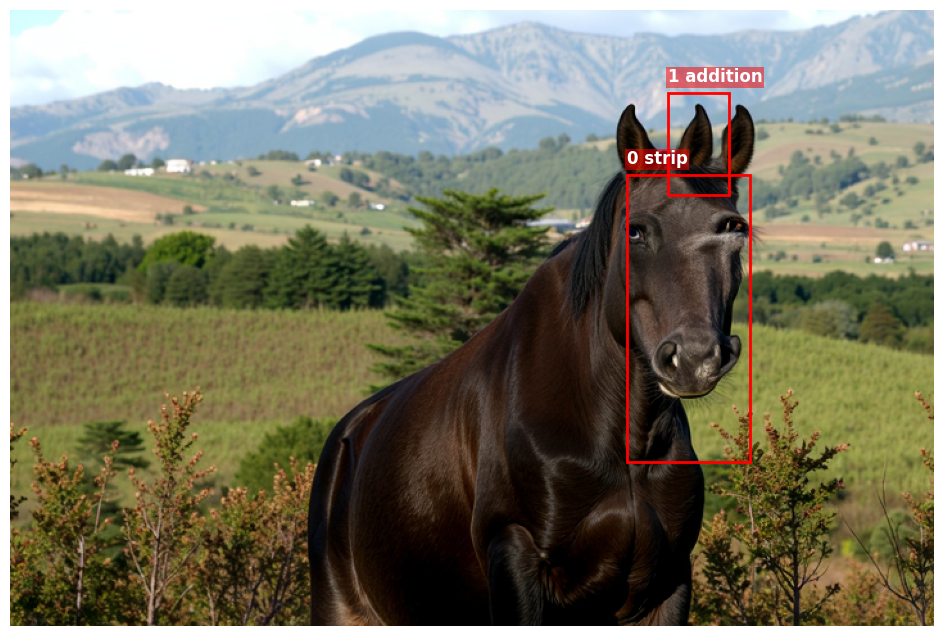

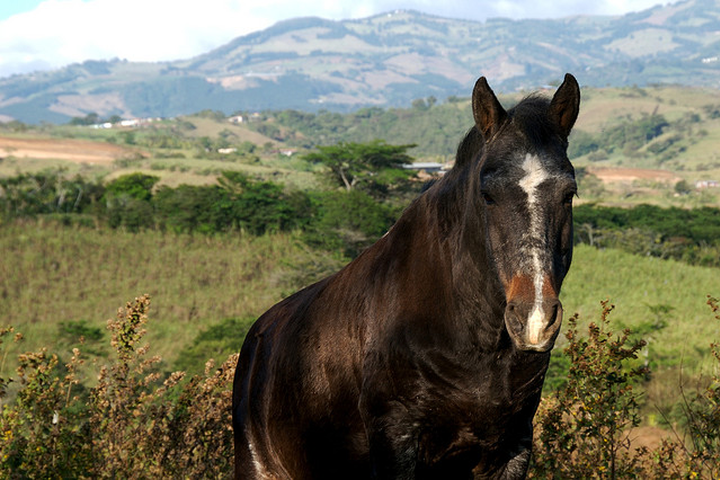

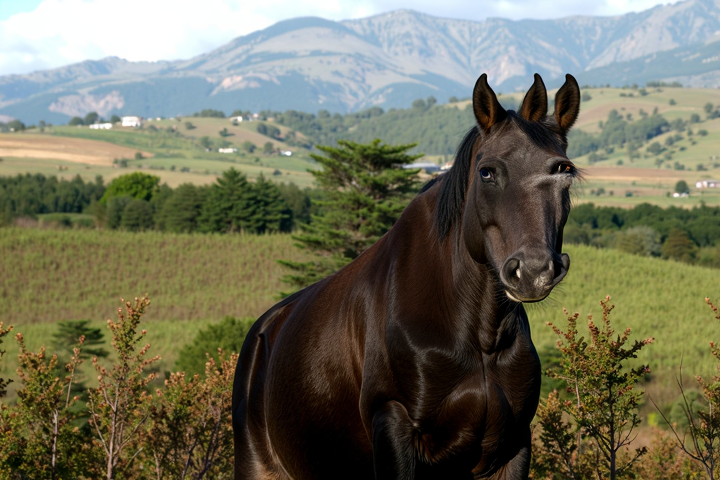

In [150]:
flux_result = next(flux_results_iter)

plot_explanations(filtered_flux_results_path, flux_result)